In [ ]:
import kagglehub
import pandas as pd
import os

# 1. Kaggle에서 데이터셋 다운로드 (arjunbhasin2013/ccdata)
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")

# 2. 다운로드된 폴더 안에서 CSV 파일 경로 확인
csv_path = os.path.join(path, "CC GENERAL.csv")

# 3. 데이터 로드
df = pd.read_csv(csv_path)

Using Colab cache for faster access to the 'ccdata' dataset.


In [ ]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df.shape

(8950, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
# 데이터에 null이 있으면 추후 클러스터링 불가
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
# df.fillna(df.mean(), inplace = True) 이렇게 실행하면 object인것도 변환하려고 하여 오류남

# dtypes가 number인 null 데이터 부분을 mean으로 채우기
df1 = df.fillna(df.select_dtypes(include=['number']).mean())

In [ ]:
df1.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
# 의미없는 변수 X(CUST_ID) 제거
df2 = df1.drop(columns = ['CUST_ID'])

In [ ]:
# 정규화
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df2) # 여기서 df_scaled는 numpy.ndarray임

In [ ]:
df_scaled # 칼럼이 전부 날아간 상태

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.31096755,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.08931021,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.10166318,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.33546549,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.34690648,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.33294642,
        -0.52555097, -4.12276757]])

In [ ]:
# 칼럼 다시 넣어주고, DataFrame 형태로 만들어주는 이 방식으로 코드 작성하기
df_scaled = pd.DataFrame(scaler.fit_transform(df2), columns = df2.columns)

In [ ]:
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-3.109675e-01,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,8.931021e-02,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-1.016632e-01,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,4.878305e-17,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-2.657913e-01,-0.525551,0.36068


y 생성 + split

pca로 분류 성능 비교를 위한 의도적으로 y값 생성

In [ ]:
!pip install koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 35.6 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# PURCHASES 기준으로 고지출(1) / 저지출(0) 이진 분류
y = (df_scaled['PURCHASES'] > 0).astype(int).values
X = df_scaled.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"저지출(0): {sum(y==0)}명, 고지출(1): {sum(y==1)}명")

X_train: (7160, 17), X_test: (1790, 17)
저지출(0): 6502명, 고지출(1): 2448명


 PCA 전 기본 모델

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("=== PCA 적용 전 ===")
print(f"변수 수: {X_train.shape[1]}개")
print(f"정확도: {accuracy_score(y_test, pred):.4f}")
print(classification_report(y_test, pred))

=== PCA 적용 전 ===
변수 수: 17개
정확도: 0.9888
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1264
           1       0.99      0.97      0.98       526

    accuracy                           0.99      1790
   macro avg       0.99      0.98      0.99      1790
weighted avg       0.99      0.99      0.99      1790



PCA

95% 분산 설명에 필요한 주성분 수: 12개 (원래 17개)


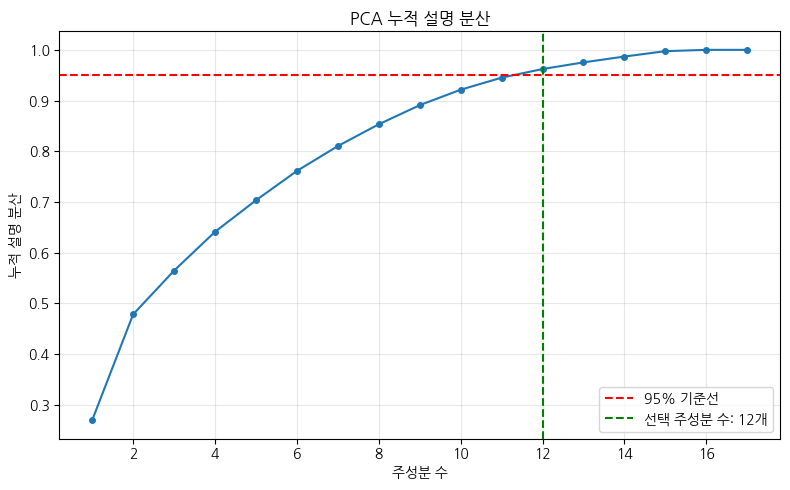

In [ ]:
import koreanize_matplotlib
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_train)

cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumsum >= 0.95) + 1
print(f"95% 분산 설명에 필요한 주성분 수: {n_components}개 (원래 {X_train.shape[1]}개)")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumsum)+1), cumsum, marker='o', markersize=4)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% 기준선')
plt.axvline(x=n_components, color='green', linestyle='--', label=f'선택 주성분 수: {n_components}개')
plt.xlabel('주성분 수')
plt.ylabel('누적 설명 분산')
plt.title('PCA 누적 설명 분산')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150)
plt.show()

In [ ]:
pca_final = PCA(n_components=n_components)
X_train_pca = pca_final.fit_transform(X_train)
X_test_pca = pca_final.transform(X_test)

model_pca = LogisticRegression(max_iter=10000, random_state=42)
model_pca.fit(X_train_pca, y_train)
pred_pca = model_pca.predict(X_test_pca)

print("=== PCA 적용 후 ===")
print(f"변수 수: {n_components}개 (주성분)")
print(f"정확도: {accuracy_score(y_test, pred_pca):.4f}")
print(classification_report(y_test, pred_pca))

=== PCA 적용 후 ===
변수 수: 12개 (주성분)
정확도: 0.9603
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1264
           1       0.95      0.91      0.93       526

    accuracy                           0.96      1790
   macro avg       0.96      0.95      0.95      1790
weighted avg       0.96      0.96      0.96      1790



In [ ]:
print("=" * 45)
print(f"{'':22} {'PCA 전':>9} {'PCA 후':>9}")
print("-" * 45)
print(f"{'변수 수':22} {X_train.shape[1]:>9} {n_components:>9}")
print(f"{'정확도':22} {accuracy_score(y_test, pred):>9.4f} {accuracy_score(y_test, pred_pca):>9.4f}")
print("=" * 45)

                           PCA 전     PCA 후
---------------------------------------------
변수 수                          17        12
정확도                       0.9888    0.9603


PCA 수정

X 변수에서 정답값 PURCHASE drop해주기

In [ ]:
X = df_scaled.drop(columns = ['PURCHASES']) # x에 정답을 제외시켜주기
y = (df_scaled['PURCHASES'] > 0).astype(int) # 0보다 크면(>) True -> 1, 0보다 작거나 같으면(<=) -> 0


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) # random_state : 매던 똑같은 랜덤 값으로 나눔

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"저지출(0): {sum(y==0)}명, 고지출(1): {sum(y==1)}명")

X_train: (7160, 16), X_test: (1790, 16)
저지출(0): 6502명, 고지출(1): 2448명


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("=== PCA 적용 전 ===")
print(f"변수 수: {X_train.shape[1]}개")
print(f"정확도: {accuracy_score(y_test, pred):.4f}")
print(classification_report(y_test, pred))

=== PCA 적용 전 ===
변수 수: 16개
정확도: 0.9860
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1264
           1       0.99      0.96      0.98       526

    accuracy                           0.99      1790
   macro avg       0.99      0.98      0.98      1790
weighted avg       0.99      0.99      0.99      1790



95% 분산 설명에 필요한 주성분 수: 12개 (원래 16개)


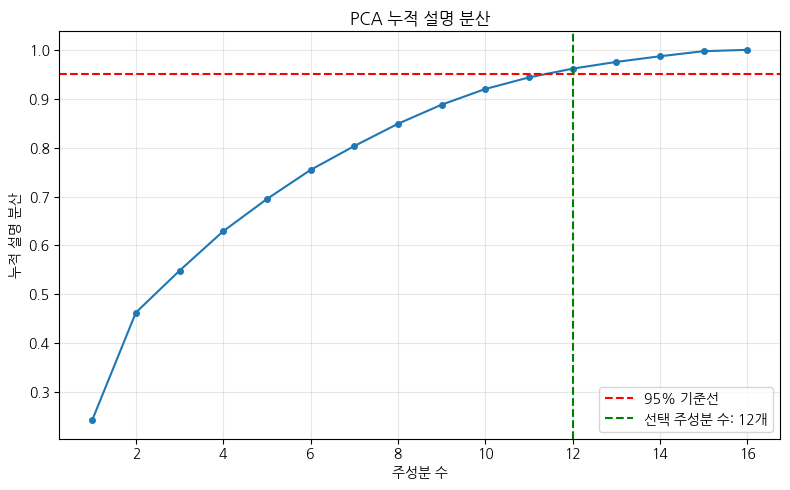

In [ ]:
import koreanize_matplotlib
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_train)

cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumsum >= 0.95) + 1
print(f"95% 분산 설명에 필요한 주성분 수: {n_components}개 (원래 {X_train.shape[1]}개)")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumsum)+1), cumsum, marker='o', markersize=4)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% 기준선')
plt.axvline(x=n_components, color='green', linestyle='--', label=f'선택 주성분 수: {n_components}개')
plt.xlabel('주성분 수')
plt.ylabel('누적 설명 분산')
plt.title('PCA 누적 설명 분산')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150)
plt.show()

In [ ]:
pca_final = PCA(n_components=n_components)
X_train_pca = pca_final.fit_transform(X_train)
X_test_pca = pca_final.transform(X_test)

model_pca = LogisticRegression(max_iter=10000, random_state=42)
model_pca.fit(X_train_pca, y_train)
pred_pca = model_pca.predict(X_test_pca)

print("=== PCA 적용 후 ===")
print(f"변수 수: {n_components}개 (주성분)")
print(f"정확도: {accuracy_score(y_test, pred_pca):.4f}")
print(classification_report(y_test, pred_pca))

=== PCA 적용 후 ===
변수 수: 12개 (주성분)
정확도: 0.9330
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      1264
           1       0.91      0.85      0.88       526

    accuracy                           0.93      1790
   macro avg       0.93      0.91      0.92      1790
weighted avg       0.93      0.93      0.93      1790



In [ ]:
print("=" * 45)
print(f"{'':22} {'PCA 전':>9} {'PCA 후':>9}")
print("-" * 45)
print(f"{'변수 수':22} {X_train.shape[1]:>9} {n_components:>9}")
print(f"{'정확도':22} {accuracy_score(y_test, pred):>9.4f} {accuracy_score(y_test, pred_pca):>9.4f}")
print("=" * 45)

                           PCA 전     PCA 후
---------------------------------------------
변수 수                          16        12
정확도                       0.9860    0.9330


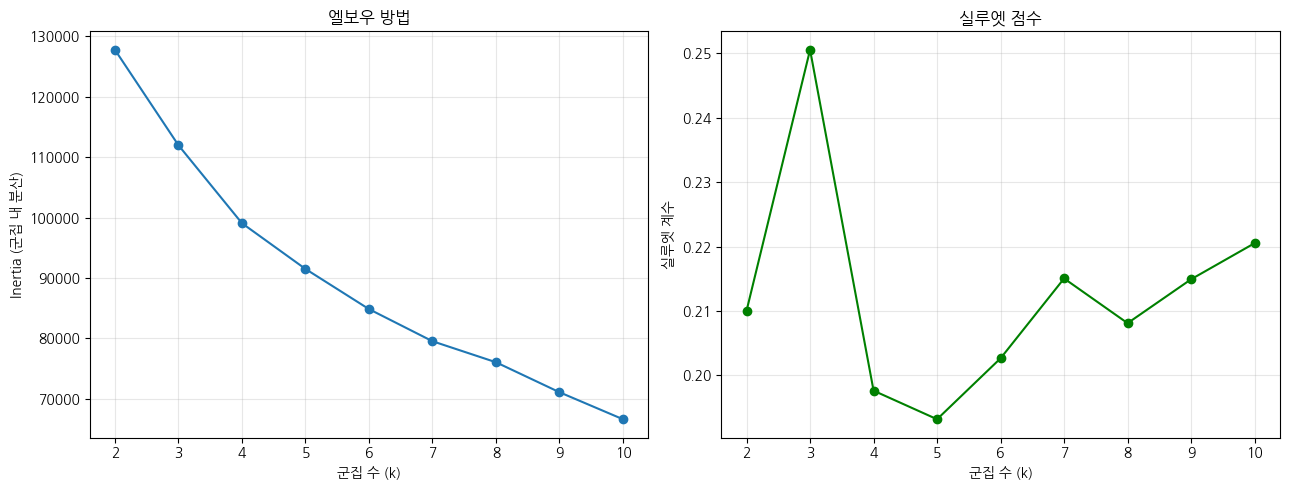

실루엣 기준 추천 k: 3  (실루엣=0.251)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(df_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 엘보우: inertia(군집 내 거리 합)가 꺾이는 지점
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_xlabel('군집 수 (k)')
axes[0].set_ylabel('Inertia (군집 내 분산)')
axes[0].set_title('엘보우 방법')
axes[0].grid(alpha=0.3)

# 실루엣: 1에 가까울수록 군집이 잘 분리됨
axes[1].plot(list(K_range), silhouettes, marker='o', color='green')
axes[1].set_xlabel('군집 수 (k)')
axes[1].set_ylabel('실루엣 계수')
axes[1].set_title('실루엣 점수')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_k_selection.png', dpi=150)
plt.show()

best_k = list(K_range)[int(np.argmax(silhouettes))]
print(f"실루엣 기준 추천 k: {best_k}  (실루엣={max(silhouettes):.3f})")

In [ ]:
k = best_k

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

print(f"최종 군집 수: {k}")
print(f"전체 실루엣 계수: {silhouette_score(df_scaled, clusters):.3f}")
print("\n군집별 고객 수:")
print(pd.Series(clusters).value_counts().sort_index())

최종 군집 수: 3
전체 실루엣 계수: 0.251

군집별 고객 수:
0    1596
1    1235
2    6119
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


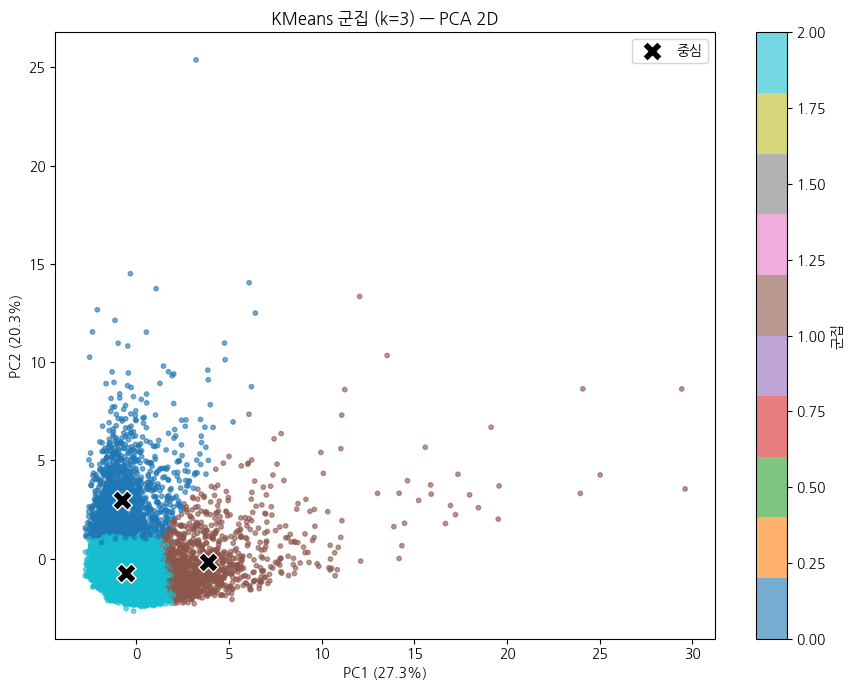

2개 주성분이 설명하는 분산: 47.6%


In [ ]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
coords = pca_2d.fit_transform(df_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=clusters,
                      cmap='tab10', s=10, alpha=0.6)

# 군집 중심도 같은 PCA 공간으로 변환해 표시
centers_2d = pca_2d.transform(kmeans.cluster_centers_)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
            c='black', marker='X', s=200, edgecolors='white', label='중심')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'KMeans 군집 (k={k}) — PCA 2D')
plt.colorbar(scatter, label='군집')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_pca_2d.png', dpi=150)
plt.show()

print(f"2개 주성분이 설명하는 분산: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


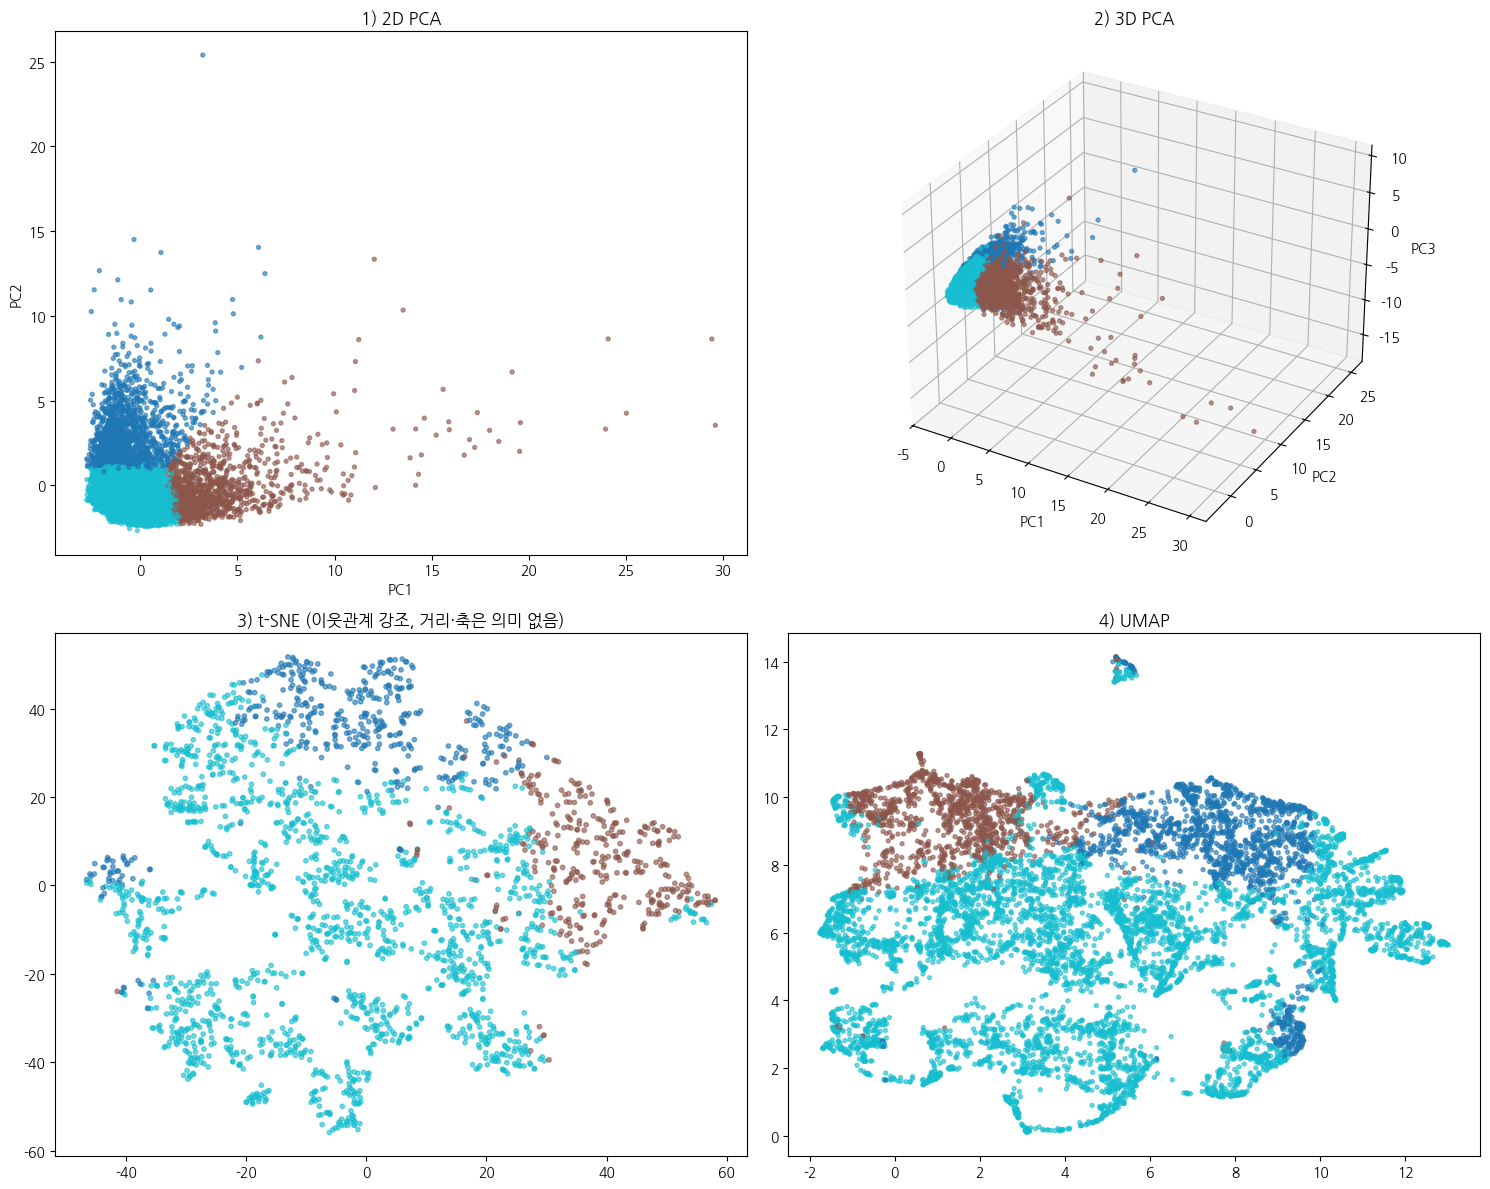

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import koreanize_matplotlib

X = df_scaled.values
k = len(np.unique(clusters))

# 차원축소 4종
c2 = PCA(n_components=2).fit_transform(X)
c3 = PCA(n_components=3).fit_transform(X)

# t-SNE는 느려서 2500개만 샘플링 (전체 쓰려면 idx = np.arange(len(X)))
idx = np.random.RandomState(42).choice(len(X), min(2500, len(X)), replace=False)
ct = TSNE(n_components=2, random_state=42, perplexity=30, init='pca').fit_transform(X[idx])

# UMAP (설치 필요: pip install umap-learn). 없으면 자동으로 건너뜀
try:
    import umap
    cu = umap.UMAP(n_components=2, random_state=42).fit_transform(X)
    has_umap = True
except ImportError:
    has_umap = False

fig = plt.figure(figsize=(15, 12))

ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(c2[:, 0], c2[:, 1], c=clusters, cmap='tab10', s=8, alpha=0.6)
ax1.set_title('1) 2D PCA'); ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')

ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.scatter(c3[:, 0], c3[:, 1], c3[:, 2], c=clusters, cmap='tab10', s=8, alpha=0.6)
ax2.set_title('2) 3D PCA'); ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_zlabel('PC3')

ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(ct[:, 0], ct[:, 1], c=clusters[idx], cmap='tab10', s=10, alpha=0.6)
ax3.set_title('3) t-SNE (이웃관계 강조, 거리·축은 의미 없음)')

ax4 = fig.add_subplot(2, 2, 4)
if has_umap:
    ax4.scatter(cu[:, 0], cu[:, 1], c=clusters, cmap='tab10', s=8, alpha=0.6)
    ax4.set_title('4) UMAP')
else:
    ax4.text(0.5, 0.5, 'UMAP 미설치\n(pip install umap-learn)', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
print(f"\nKMeans 군집별 인원:")
print(pd.Series(clusters).value_counts().sort_index())


KMeans 군집별 인원:
0    1596
1    1235
2    6119
Name: count, dtype: int64


In [ ]:
# 스케일링 전 원본 값(df2)에 군집 라벨을 붙여 평균 비교
profile = df2.copy()
profile['cluster'] = clusters

cluster_summary = profile.groupby('cluster').mean().round(1)
print("군집별 평균 (원래 단위):")
cluster_summary


KMeans 군집별 인원:
0    1596
1    1235
2    6119
Name: count, dtype: int64
군집별 평균 (원래 단위):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,3989.3,1.0,384.5,248.7,135.9,3869.9,0.2,0.1,0.1,0.4,12.4,5.6,6683.0,3018.9,1795.7,0.0,11.4
1,2220.0,1.0,4268.5,2717.8,1551.2,458.4,0.9,0.7,0.7,0.1,1.5,56.5,7734.0,4151.3,1224.5,0.3,11.9
2,799.7,0.8,505.5,253.1,252.7,329.9,0.5,0.1,0.3,0.1,1.2,8.7,3269.8,909.7,548.5,0.2,11.5


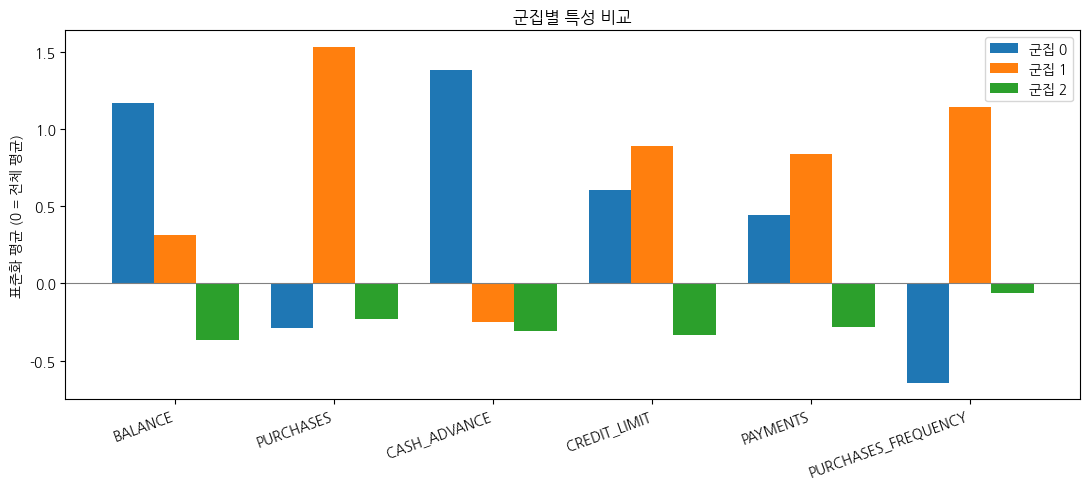

In [ ]:
key = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES_FREQUENCY']
key = [c for c in key if c in df_scaled.columns]

prof = df_scaled.copy()
prof['cluster'] = clusters
m = prof.groupby('cluster')[key].mean()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(key))
w = 0.8 / k
for i in range(k):
    ax.bar(x + i * w, m.iloc[i].values, w, label=f'군집 {i}')
ax.set_xticks(x + w * (k - 1) / 2)
ax.set_xticklabels(key, rotation=20, ha='right')
ax.set_ylabel('표준화 평균 (0 = 전체 평균)')
ax.set_title('군집별 특성 비교')
ax.axhline(0, color='gray', lw=0.8)
ax.legend()
plt.tight_layout()
plt.show()

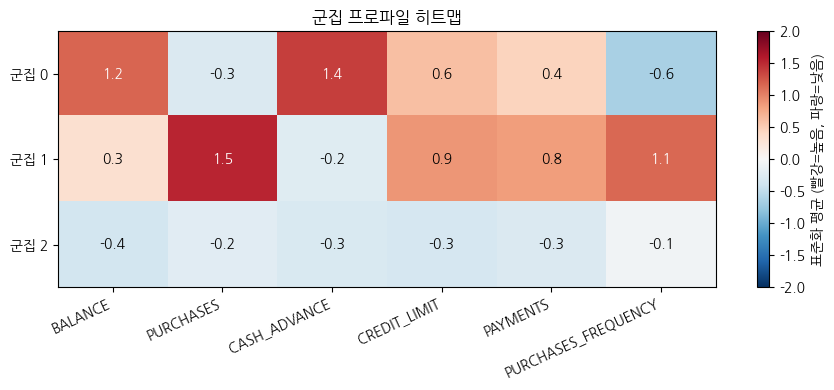

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

key = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES_FREQUENCY']
key = [c for c in key if c in df_scaled.columns]
prof = df_scaled.copy()
prof['cluster'] = clusters
m = prof.groupby('cluster')[key].mean()
k = len(m)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(m.values, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
ax.set_xticks(range(len(key)))
ax.set_xticklabels(key, rotation=25, ha='right')
ax.set_yticks(range(k))
ax.set_yticklabels([f'군집 {i}' for i in range(k)])
for i in range(k):
    for j in range(len(key)):
        v = m.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                color='white' if abs(v) > 1 else 'black')
plt.colorbar(im, label='표준화 평균 (빨강=높음, 파랑=낮음)')
ax.set_title('군집 프로파일 히트맵')
plt.tight_layout()
plt.show()

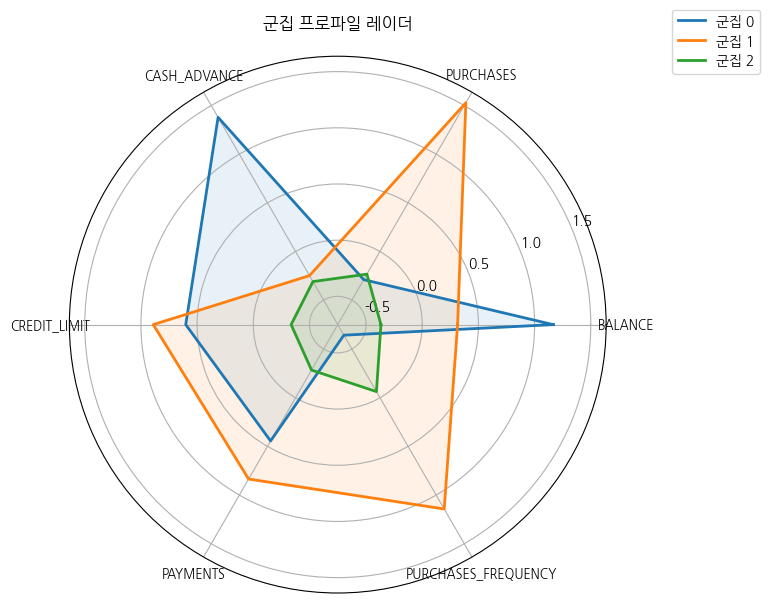

In [ ]:
from math import pi

angles = [n / len(key) * 2 * pi for n in range(len(key))] + [0]
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for i in range(k):
    vals = m.iloc[i].tolist() + [m.iloc[i].tolist()[0]]
    ax.plot(angles, vals, color=colors[i], lw=2, label=f'군집 {i}')
    ax.fill(angles, vals, color=colors[i], alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(key, fontsize=9)
ax.set_title('군집 프로파일 레이더', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [ ]:
profile_raw = df2.copy()
profile_raw['cluster'] = clusters
profile_raw.groupby('cluster')[key].mean().round(1)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY
cluster,,,,,,
0,3989.3,384.5,3869.9,6683.0,3018.9,0.2
1,2220.0,4268.5,458.4,7734.0,4151.3,0.9
2,799.7,505.5,329.9,3269.8,909.7,0.5


GMM_FULL 클러스터링

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

# K-means와 동일한 k=3으로 학습해 비교 (BIC가 더 큰 k를 추천해도, 비교 목적상 3 고정)
gmm = GaussianMixture(n_components=3, random_state=42, n_init=5)
clusters_gmm = gmm.fit_predict(df_scaled)
probs = gmm.predict_proba(df_scaled)   # 각 점의 군집별 소속 확률

print(f"GMM 군집별 인원:\n{pd.Series(clusters_gmm).value_counts().sort_index()}")
print(f"\nGMM 실루엣 계수: {silhouette_score(df_scaled, clusters_gmm):.3f}")
print(f"K-means 실루엣 계수: {silhouette_score(df_scaled, clusters):.3f}  (비교용)")

GMM 군집별 인원:
0    3990
1    2846
2    2114
Name: count, dtype: int64

GMM 실루엣 계수: 0.114
K-means 실루엣 계수: 0.251  (비교용)


In [ ]:
from sklearn.metrics import adjusted_rand_score

# ARI: 두 군집 결과가 얼마나 일치하는가 (1=완전 일치, 0=무작위 수준)
ari = adjusted_rand_score(clusters, clusters_gmm)
print(f"K-means vs GMM 일치도 (ARI): {ari:.3f}")
print("  → 1에 가까우면 두 방법 결과가 거의 같음 (결과가 견고하다는 증거)")
print("  → 0에 가까우면 두 방법이 다른 군집을 찾았다는 뜻\n")

# 교차표: 두 방법이 같은 고객을 어떻게 다르게 분류했는가
crosstab = pd.crosstab(
    pd.Series(clusters, name='K-means'),
    pd.Series(clusters_gmm, name='GMM')
)
print("두 방법 군집 매칭 (교차표):")
print(crosstab)

K-means vs GMM 일치도 (ARI): 0.126
  → 1에 가까우면 두 방법 결과가 거의 같음 (결과가 견고하다는 증거)
  → 0에 가까우면 두 방법이 다른 군집을 찾았다는 뜻

두 방법 군집 매칭 (교차표):
GMM         0     1    2
K-means                 
0           2  1003  591
1         700     0  535
2        3288  1843  988


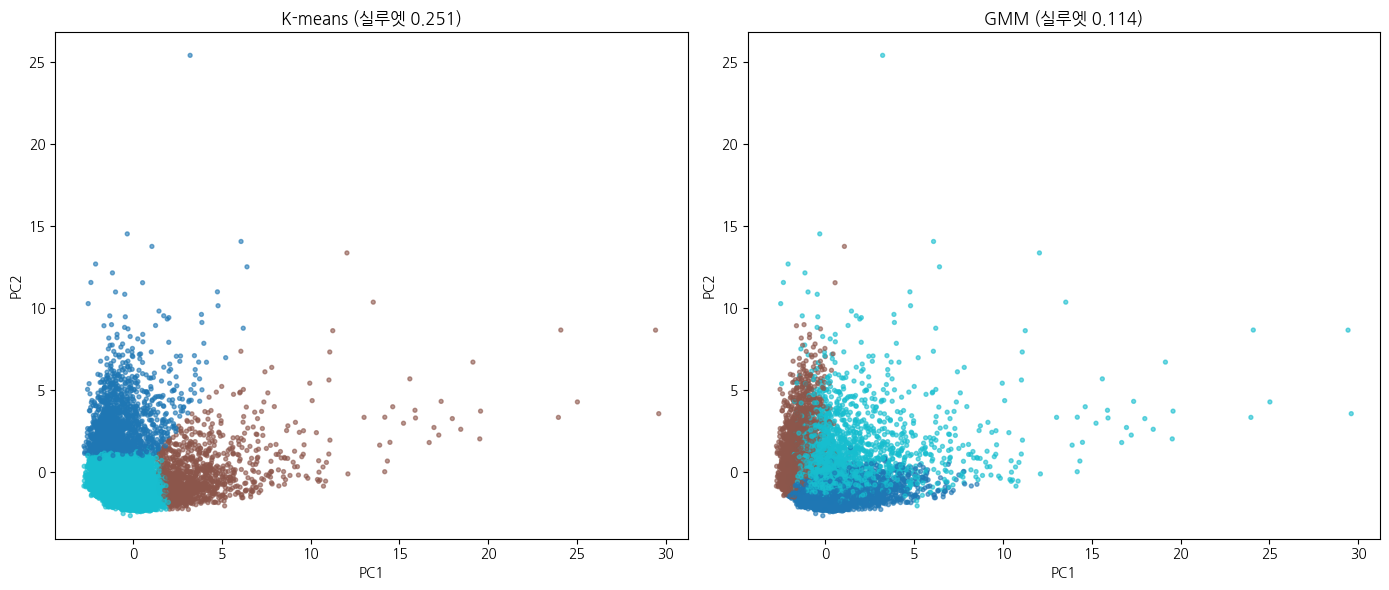

In [ ]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2).fit_transform(df_scaled.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='tab10', s=8, alpha=0.6)
axes[0].set_title(f'K-means (실루엣 {silhouette_score(df_scaled, clusters):.3f})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(coords[:, 0], coords[:, 1], c=clusters_gmm, cmap='tab10', s=8, alpha=0.6)
axes[1].set_title(f'GMM (실루엣 {silhouette_score(df_scaled, clusters_gmm):.3f})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [ ]:
# 각 고객의 "최대 소속 확률"을 보면, 낮을수록 군집 경계에 있는 애매한 고객
max_prob = probs.max(axis=1)

print(f"확률 분포:")
print(f"  매우 확실 (≥0.9): {(max_prob >= 0.9).sum()}명")
print(f"  보통 (0.7~0.9):   {((max_prob >= 0.7) & (max_prob < 0.9)).sum()}명")
print(f"  경계 (<0.7):      {(max_prob < 0.7).sum()}명")

# 경계 고객의 확률 분포 확인 (어느 군집들 사이에서 흔들리는지)
border = pd.DataFrame(probs, columns=[f'P(군집{i})' for i in range(3)])
border['최대확률'] = max_prob
border['배정군집'] = clusters_gmm
print("\n경계 고객(최대확률<0.7) 샘플 5명:")
print(border[border['최대확률'] < 0.7].head().round(2))

확률 분포:
  매우 확실 (≥0.9): 8841명
  보통 (0.7~0.9):   67명
  경계 (<0.7):      42명

경계 고객(최대확률<0.7) 샘플 5명:
     P(군집0)  P(군집1)  P(군집2)  최대확률  배정군집
190    0.52    0.48    0.00  0.52     0
343    0.35    0.65    0.00  0.65     1
375    0.38    0.62    0.00  0.62     1
440    0.42    0.58    0.00  0.58     1
544    0.53    0.00    0.47  0.53     0


In [ ]:
# GMM 군집의 정체 파악
key = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES_FREQUENCY']
key = [c for c in key if c in df2.columns]

profile_gmm = df2.copy()
profile_gmm['cluster'] = clusters_gmm
print("GMM 군집별 평균 (원래 단위):")
print(profile_gmm.groupby('cluster')[key].mean().round(1))
print(f"\nGMM 군집별 인원:")
print(pd.Series(clusters_gmm).value_counts().sort_index())

GMM 군집별 평균 (원래 단위):
         BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  \
cluster                                                             
0          611.8     1114.5           0.0        4277.8    1161.1   
1         1956.4       57.0        1723.7        3977.6    1478.3   
2         2835.0     2066.9        1823.7        5599.2    3156.0   

         PURCHASES_FREQUENCY  
cluster                       
0                        0.7  
1                        0.0  
2                        0.7  

GMM 군집별 인원:
0    3990
1    2846
2    2114
Name: count, dtype: int64


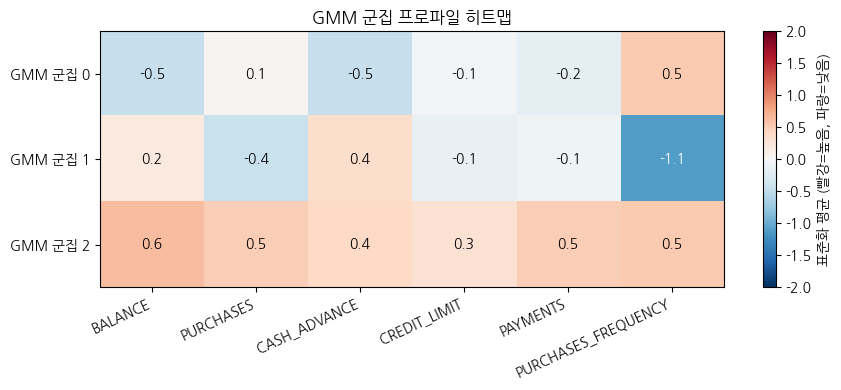

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

key = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES_FREQUENCY']
key = [c for c in key if c in df_scaled.columns]

prof_gmm = df_scaled.copy()
prof_gmm['cluster'] = clusters_gmm
m_gmm = prof_gmm.groupby('cluster')[key].mean()
k = len(m_gmm)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(m_gmm.values, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
ax.set_xticks(range(len(key)))
ax.set_xticklabels(key, rotation=25, ha='right')
ax.set_yticks(range(k))
ax.set_yticklabels([f'GMM 군집 {i}' for i in range(k)])
for i in range(k):
    for j in range(len(key)):
        v = m_gmm.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                color='white' if abs(v) > 1 else 'black')
plt.colorbar(im, label='표준화 평균 (빨강=높음, 파랑=낮음)')
ax.set_title('GMM 군집 프로파일 히트맵')
plt.tight_layout()
plt.show()

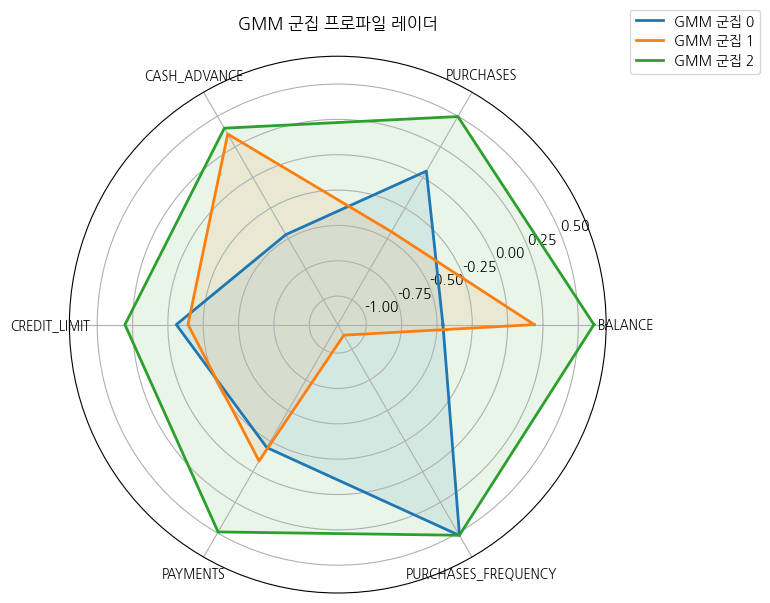

In [ ]:
from math import pi

angles = [n / len(key) * 2 * pi for n in range(len(key))] + [0]
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for i in range(k):
    vals = m_gmm.iloc[i].tolist() + [m_gmm.iloc[i].tolist()[0]]
    ax.plot(angles, vals, color=colors[i], lw=2, label=f'GMM 군집 {i}')
    ax.fill(angles, vals, color=colors[i], alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(key, fontsize=9)
ax.set_title('GMM 군집 프로파일 레이더', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

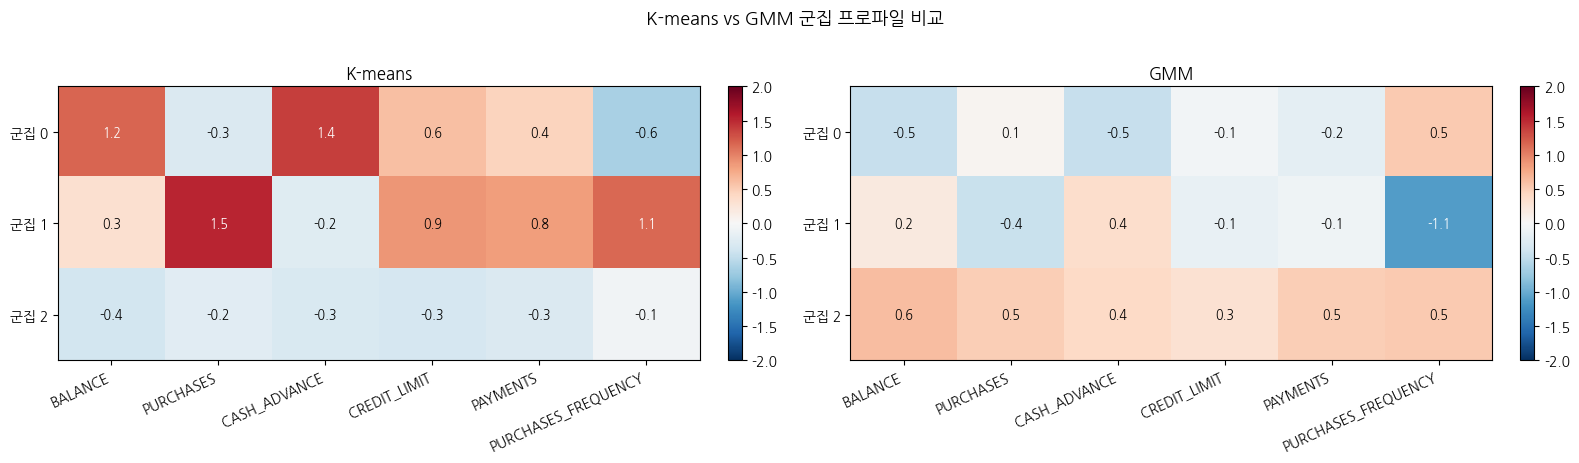

In [ ]:
key = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES_FREQUENCY']
key = [c for c in key if c in df_scaled.columns]

prof_km = df_scaled.copy(); prof_km['cluster'] = clusters
prof_gm = df_scaled.copy(); prof_gm['cluster'] = clusters_gmm
m_km = prof_km.groupby('cluster')[key].mean()
m_gm = prof_gm.groupby('cluster')[key].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

for ax, m, title in [(axes[0], m_km, 'K-means'), (axes[1], m_gm, 'GMM')]:
    im = ax.imshow(m.values, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
    ax.set_xticks(range(len(key)))
    ax.set_xticklabels(key, rotation=25, ha='right')
    ax.set_yticks(range(len(m)))
    ax.set_yticklabels([f'군집 {i}' for i in range(len(m))])
    for i in range(len(m)):
        for j in range(len(key)):
            v = m.values[i, j]
            ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                    color='white' if abs(v) > 1 else 'black', fontsize=9)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('K-means vs GMM 군집 프로파일 비교', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# PCA로 95% 분산까지 줄인 데이터로 KMeans
pca_for_cluster = PCA(n_components=0.95)
df_pca = pca_for_cluster.fit_transform(df_scaled)

kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(df_pca)

print(f"원본(16D) 실루엣: {silhouette_score(df_scaled, clusters):.3f}")
print(f"PCA({df_pca.shape[1]}D) 실루엣: {silhouette_score(df_pca, clusters_pca):.3f}")
print(f"두 결과 일치도(ARI): {adjusted_rand_score(clusters, clusters_pca):.3f}")

원본(16D) 실루엣: 0.251
PCA(12D) 실루엣: 0.253
두 결과 일치도(ARI): 0.992
